### Project 2 for data collection and preprocessing for training a ML model

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as war
war.filterwarnings('ignore')

df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [84]:
df.shape

(918, 12)

In [85]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [86]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

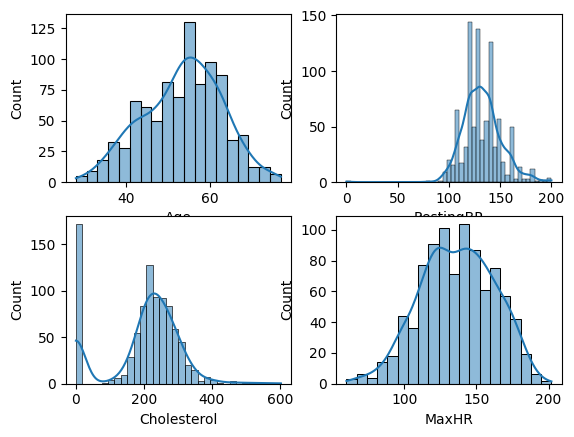

In [87]:
def plot(col, num): 
    plt.subplot(2, 2, num)
    sns.histplot(df, x = col, kde=True)

num = 1
quant_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
for col in quant_col: 
    plot(col, num)
    num += 1

In [88]:
Cholesterol_mean = np.mean(df[df['Cholesterol'] != 0]['Cholesterol'])
print(Cholesterol_mean)
df['Cholesterol'].replace(0, Cholesterol_mean, inplace=True)


restingBP_mean = np.mean(df[df['RestingBP'] != 0]['RestingBP'])
df['RestingBP'].replace(0, restingBP_mean, inplace=True)

244.6353887399464


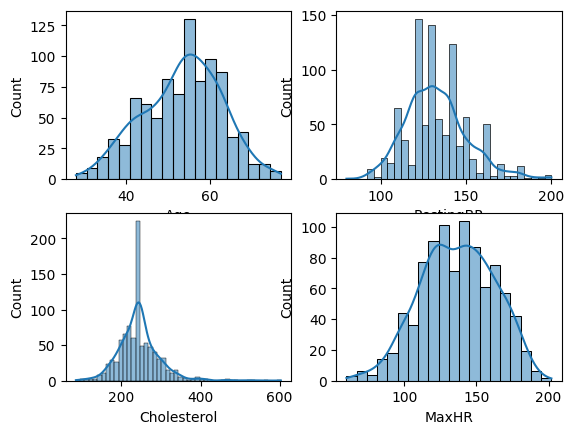

In [89]:
def plot(col, num): 
    plt.subplot(2, 2, num)
    sns.histplot(df, x = col, kde=True)

num = 1
quant_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
for col in quant_col: 
    plot(col, num)
    num += 1

In [90]:
df.head()
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [91]:
df = df.astype(int)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [92]:
df.dtypes

Age                  int64
RestingBP            int64
Cholesterol          int64
FastingBS            int64
MaxHR                int64
Oldpeak              int64
HeartDisease         int64
Sex_M                int64
ChestPainType_ATA    int64
ChestPainType_NAP    int64
ChestPainType_TA     int64
RestingECG_Normal    int64
RestingECG_ST        int64
ExerciseAngina_Y     int64
ST_Slope_Flat        int64
ST_Slope_Up          int64
dtype: object

In [93]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [94]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
df[col] = scaler.fit_transform(df[col])

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,0,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,1,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,0,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,1,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,0,0,1,0,1,0,1,0,0,0,1


In [95]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [96]:
cat_col = ['FastingBS', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}

for col in cat_col:
    contingency = pd.crosstab(df[col], df['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df

,Decision
FastingBS,Reject Null (Keep Feature)
Oldpeak,Reject Null (Keep Feature)
Sex_M,Reject Null (Keep Feature)
ChestPainType_ATA,Reject Null (Keep Feature)
ChestPainType_NAP,Reject Null (Keep Feature)
ChestPainType_TA,Accept Null (Drop Feature)
RestingECG_Normal,Reject Null (Keep Feature)
RestingECG_ST,Reject Null (Keep Feature)
ExerciseAngina_Y,Reject Null (Keep Feature)
ST_Slope_Flat,Reject Null (Keep Feature)


In [97]:
df.drop('ChestPainType_TA', inplace=True, axis=1)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,0,0,1,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,1,1,0,0,1,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,0,0,1,1,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,1,1,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,0,0,1,0,1,1,0,0,0,1
